# Group 1 Exploration — Location & Conditions

Columns: STREET1, STREET2, ROAD_CLASS, DISTRICT, LATITUDE, LONGITUDE, ACCLOC, TRAFFCTL, VISIBILITY, LIGHT, RDSFCOND, DIVISION, NEIGHBOURHOOD_158, HOOD_158, DATE, TIME

**Status: draft built as a safety net — Aboud, please review, adjust, and add your own commentary/interpretation before we submit.**

In [1]:
import pandas as pd

df = pd.read_csv('../data/TOTAL_KSI_4115794401574937330.csv', encoding='utf-8-sig')
df = df[df['ACCLASS'].notna() & (df['ACCLASS'].str.strip() != '')]
df['FATAL'] = df['ACCLASS'].apply(lambda x: 1 if str(x).strip().lower() == 'fatal' else 0)
print('Rows:', len(df))
print('Overall fatal rate: {:.2f}%'.format(df['FATAL'].mean() * 100))

Rows: 18956
Overall fatal rate: 14.09%


## Missing data & cardinality check

In [2]:
cols = ['STREET1','STREET2','ROAD_CLASS','DISTRICT','LATITUDE','LONGITUDE','ACCLOC',
        'TRAFFCTL','VISIBILITY','LIGHT','RDSFCOND','DIVISION','NEIGHBOURHOOD_158',
        'HOOD_158','DATE','TIME']

summary = pd.DataFrame({
    'missing_pct': [df[c].isna().mean()*100 for c in cols],
    'n_unique': [df[c].nunique() for c in cols],
}, index=cols)
summary.round(1)

,missing_pct,n_unique
STREET1,0.0,1942
STREET2,9.0,2821
ROAD_CLASS,2.6,11
DISTRICT,1.2,4
LATITUDE,0.0,4782
LONGITUDE,0.0,5201
ACCLOC,28.8,10
TRAFFCTL,0.4,10
VISIBILITY,0.1,8
LIGHT,0.0,9


**Findings:** Most columns are close to fully populated. `ACCLOC` is the most incomplete at 28.8% missing — worth deciding whether to impute ("Unknown" category) or drop. `STREET2` is 9% missing (makes sense — not every collision happens at an intersection of two named streets).

**High-cardinality columns to handle carefully:** `STREET1` (1,942 unique), `STREET2` (2,821), `LATITUDE`/`LONGITUDE` (~4,800-5,200 unique), `DATE` (4,128), `TIME` (1,341), and `NEIGHBOURHOOD_158`/`HOOD_158` (159 each). One-hot encoding these directly would blow up the feature space — `NEIGHBOURHOOD_158` might be usable as-is (159 categories is a lot but feasible), but `STREET1`/`STREET2`/exact lat-long are probably too granular for a first model and should either be dropped, or used to engineer coarser features (e.g. this notebook derives HOUR from TIME below as one example).

## Fatal rate by category — low-cardinality columns

In [3]:
for c in ['ROAD_CLASS','DISTRICT','TRAFFCTL','VISIBILITY','LIGHT','RDSFCOND','ACCLOC']:
    g = df.groupby(c)['FATAL'].agg(['mean','count']).sort_values('mean', ascending=False)
    g['mean'] = (g['mean']*100).round(2)
    print(f'--- {c} ---')
    print(g.to_string())
    print()

--- ROAD_CLASS ---
                  mean  count
ROAD_CLASS                   
Laneway          54.55     11
Expressway Ramp  42.86     14
Major Arterial   30.77     13
Expressway       17.68    164
Major Arterial   14.20  13376
Collector        13.95   1032
Minor Arterial   13.36   2957
Local            12.37    865
Major Shoreline   0.00      6
Other             0.00     25
Pending           0.00      7

--- DISTRICT ---
                        mean  count
DISTRICT                           
Scarborough            18.41   4270
North York             15.34   3788
Etobicoke York         14.39   4342
Toronto and East York  10.53   6327

--- TRAFFCTL ---
                       mean  count
TRAFFCTL                          
Traffic Gate          60.00      5
No Control            15.92   9020
Pedestrian Crossover  13.46    208
Traffic Signal        12.74   8035
Stop Sign             11.89   1464
Police Control         0.00      2
School Guard           0.00      2
Streetcar (Stop for)   0

**Findings:**

- **DISTRICT:** Scarborough has the highest fatal rate (18.4%), Toronto and East York the lowest (10.5%) — only 4 categories, clean and usable as-is.
- **ROAD_CLASS:** Laneway and Expressway Ramp show very high fatal rates but tiny sample sizes (11 and 14 records) — likely noise, not a reliable pattern. Major Arterial/Expressway (larger samples) show a more believable elevated rate.
- **TRAFFCTL:** No Control (15.9%) has a notably higher fatal rate than Traffic Signal (12.7%) or Stop Sign (11.9%) — makes intuitive sense (uncontrolled intersections are riskier).
- **LIGHT:** Dark conditions (17.4%) and Dawn (16.1%) show higher fatal rates than Daylight (12.6%) — visibility plausibly matters.
- **RDSFCOND:** Counterintuitively, Dry roads (14.0%) have a *higher* fatal rate than Wet (13.6%), Snow (9.3%), or Ice (3.9%). Likely reflects that people drive faster/less cautiously on dry roads, or that snow/ice conditions cause more (survivable) low-speed collisions rather than fewer collisions overall.
- **ACCLOC:** Non-Intersection collisions have a higher fatal rate (19.3%) than At Intersection (12.8%) — possibly related to speed (higher speeds between intersections vs. slower turning/stopping traffic at intersections).

## Time-of-day pattern (engineered feature)

`TIME` is stored as HHMM without leading zeros (e.g. 236 = 2:36 AM). Deriving an HOUR feature makes it usable and interpretable.

In [4]:
df['HOUR'] = (df['TIME'] // 100).clip(0, 23)
hourly = df.groupby('HOUR')['FATAL'].agg(['mean','count'])
hourly['mean'] = hourly['mean'] * 100
hourly.round(2)

,mean,count
HOUR,,
0,16.83,630
1,16.82,446
2,15.02,506
3,15.32,457
4,17.53,194
5,26.60,312
6,19.16,574
7,13.49,593
8,10.17,708


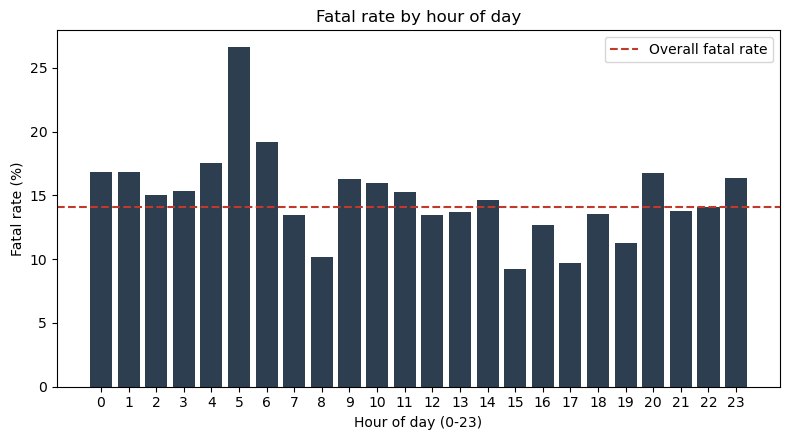

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(hourly.index, hourly['mean'], color='#2c3e50')
ax.axhline(df['FATAL'].mean()*100, color='#c0392b', linestyle='--', label='Overall fatal rate')
ax.set_xlabel('Hour of day (0-23)')
ax.set_ylabel('Fatal rate (%)')
ax.set_title('Fatal rate by hour of day')
ax.set_xticks(range(0,24))
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** 5 AM stands out sharply (26.6% fatal rate, though a smaller sample of 312 records) — early-morning hours (4-6 AM) generally run higher than mid-morning/afternoon. Late afternoon (3-5 PM, high traffic volume) shows some of the *lowest* fatal rates (~9-13%), consistent with slower-moving congested traffic being less deadly even if collisions are more frequent. This is a reasonable engineered feature to keep for modelling instead of raw TIME.

## District chart

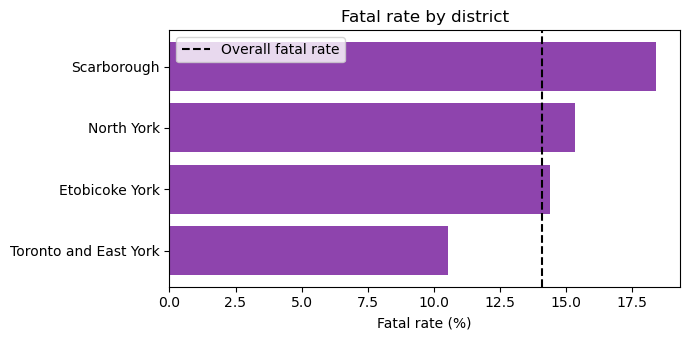

In [6]:
dist = df.groupby('DISTRICT')['FATAL'].mean().sort_values(ascending=True) * 100
fig, ax = plt.subplots(figsize=(7,3.5))
ax.barh(dist.index, dist.values, color='#8e44ad')
ax.axvline(df['FATAL'].mean()*100, color='black', linestyle='--', label='Overall fatal rate')
ax.set_xlabel('Fatal rate (%)')
ax.set_title('Fatal rate by district')
ax.legend()
plt.tight_layout()
plt.show()

## Summary / recommendations for the modelling pipeline

**Final decisions (implemented in `KSI.py`):**

**Kept, low-cardinality, clean:** DISTRICT, TRAFFCTL, VISIBILITY, LIGHT, RDSFCOND, ACCLOC, ROAD_CLASS, NEIGHBOURHOOD_158, DIVISION — one-hot encoded, missing values imputed with the most frequent category.

**Kept as numeric:** LATITUDE, LONGITUDE — median-imputed and standard-scaled.

**Engineered instead of raw:** HOUR derived from TIME (done above) — DATE and TIME themselves are dropped in favor of this feature.

**Dropped:** STREET1, STREET2 (too high-cardinality — 1,942 / 2,821 unique values, would blow up the one-hot feature space) and HOOD_158 (redundant numeric ID duplicate of NEIGHBOURHOOD_158, same relationship as the HOOD_140/NEIGHBOURHOOD_140 pair already dropped).

**Missing data:** ACCLOC's 28.8% missing is handled via most-frequent-value imputation in the pipeline, consistent with the other categorical columns.